[FOUND] train.csv -> /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
[FOUND] test.csv -> /kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv
[FOUND] sample_submission.csv -> /kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
Train Shape:  (1460, 81)
Test Shape:   (1459, 80)

--- Train Null Count ---
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


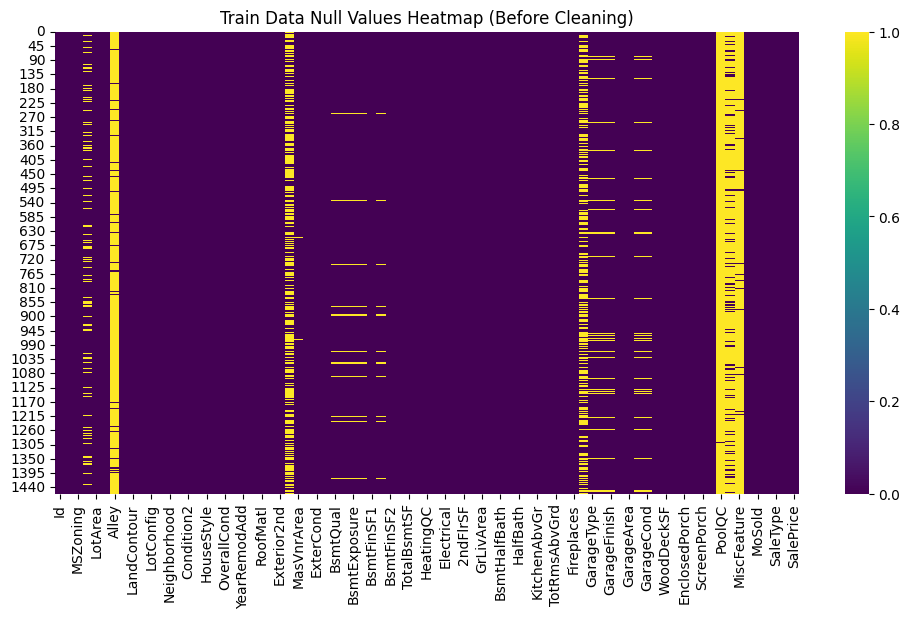


--- Test Null Count ---
Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


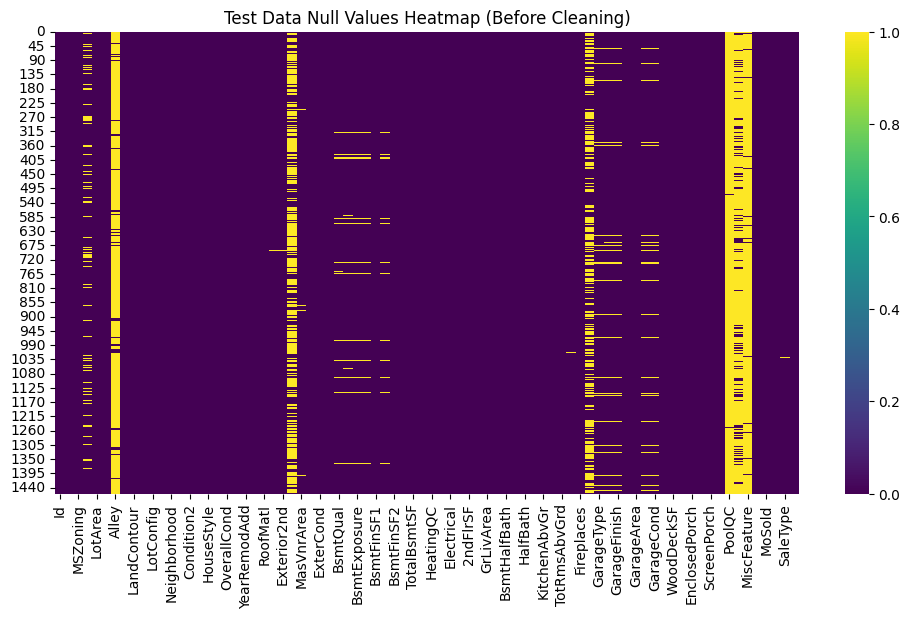

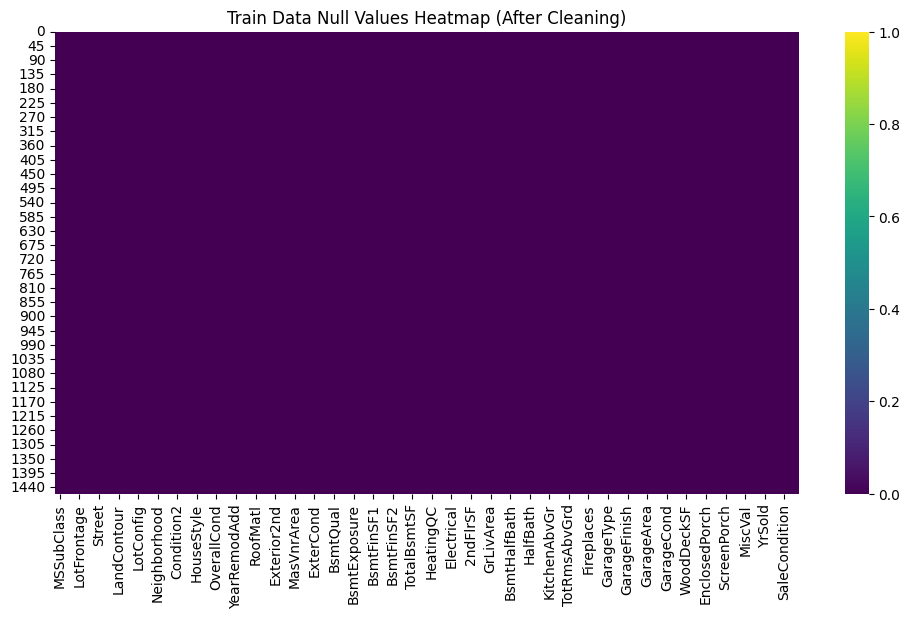

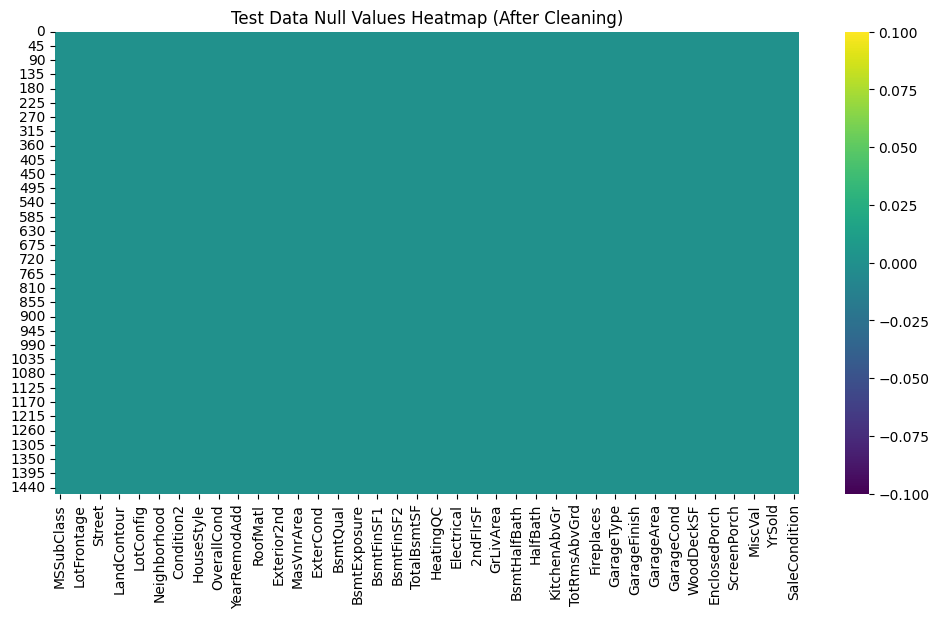

Train Shape after cleaning:  (1460, 76)
Test Shape after cleaning:   (1459, 75)
Combined final_df Shape:  (2919, 76)
Encoding: MSZoning
Encoding: Street
Encoding: LotShape
Encoding: LandContour
Encoding: Utilities
Encoding: LotConfig
Encoding: LandSlope
Encoding: Neighborhood
Encoding: Condition1
Encoding: Condition2
Encoding: BldgType
Encoding: HouseStyle
Encoding: RoofStyle
Encoding: RoofMatl
Encoding: Exterior1st
Encoding: Exterior2nd
Encoding: MasVnrType
Encoding: ExterQual
Encoding: ExterCond
Encoding: Foundation
Encoding: BsmtQual
Encoding: BsmtCond
Encoding: BsmtExposure
Encoding: BsmtFinType1
Encoding: BsmtFinType2
Encoding: Heating
Encoding: HeatingQC
Encoding: CentralAir
Encoding: Electrical
Encoding: KitchenQual
Encoding: Functional
Encoding: FireplaceQu
Encoding: GarageType
Encoding: GarageFinish
Encoding: GarageQual
Encoding: GarageCond
Encoding: PavedDrive
Encoding: SaleType
Encoding: SaleCondition
final_df Shape after One-Hot Encoding:  (2919, 176)
Processed Train Shape:

ANN Model saved to 'nn_model.h5'
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ANN Prediction Shape:  (1459, 1)
ANN submission saved to 'sample_sub_nn.csv'

=== All Steps Completed Successfully matching Rishabh Nimje's Notebook! ===


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 0. AUTOMATIC FILE LOCATION 
def get_kaggle_file_path(filename):
    search_dirs = ['/kaggle/input', '.']
    for search_dir in search_dirs:
        if os.path.exists(search_dir):
            for root, _, files in os.walk(search_dir):
                if filename in files:
                    found_path = os.path.join(root, filename)
                    print(f"[FOUND] {filename} -> {found_path}")
                    return found_path
    return filename

train_file = get_kaggle_file_path('train.csv')
test_file = get_kaggle_file_path('test.csv')
sample_sub_file = get_kaggle_file_path('sample_submission.csv')

# 1. LOAD DATA & INITIAL EDA 
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)

print("Train Shape: ", train.shape) 
print("Test Shape:  ", test.shape)  

# 2. CHECK MISSING VALUES & VISUALIZE HEATMAPS BEFORE CLEANING 
print("\n--- Train Null Count ---")
print(train.isnull().sum())

# Map 1: Train Null Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=True, cmap='viridis')
plt.title("Train Data Null Values Heatmap (Before Cleaning)")
plt.show()

print("\n--- Test Null Count ---")
print(test.isnull().sum())

# Map 2: Test Null Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(test.isnull(), cbar=True, cmap='viridis')
plt.title("Test Data Null Values Heatmap (Before Cleaning)")
plt.show()

# 3. HANDLING NULL DATA & DROPPING HIGH-NULL COLUMNS 
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'GarageQual', 'GarageCond']

ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                'KitchenQual', 'Functional', 'SaleType']

ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

# Drop High Null Columns (>70%) and 'Id' safely
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train.drop(columns=[col for col in to_drop if col in train.columns], inplace=True)
test.drop(columns=[col for col in to_drop if col in test.columns], inplace=True)

# Map 3: Train Null Heatmap After Cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=True, cmap='viridis')
plt.title("Train Data Null Values Heatmap (After Cleaning)")
plt.show()

# Map 4: Test Null Heatmap After Cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(test.isnull(), cbar=True, cmap='viridis')
plt.title("Test Data Null Values Heatmap (After Cleaning)")
plt.show()

print("Train Shape after cleaning: ", train.shape) 
print("Test Shape after cleaning:  ", test.shape)  

# 4. ONE-HOT ENCODING VIA CONCAT 
final_df = pd.concat([train, test], axis=0)
print("Combined final_df Shape: ", final_df.shape) 

all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
               'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
               'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
               'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
               'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
               'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

def cat_onehot_encoding(multicol):
    global final_df
    df_final = final_df
    i = 0
    for fields in multicol:
        print("Encoding:", fields)
        df1 = pd.get_dummies(final_df[fields], drop_first=True, dtype=float)
        final_df.drop([fields], axis=1, inplace=True, errors='ignore')
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)
        i = i + 1
    df_final = pd.concat([final_df, df_final], axis=1)
    return df_final

final_df = cat_onehot_encoding(all_cat_col)
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

print("final_df Shape after One-Hot Encoding: ", final_df.shape) 

# Split back to Train and Test sets safely
df_train = final_df.iloc[:len(train), :].copy()
df_test = final_df.iloc[len(train):, :].copy()

# Safe drop of SalePrice from df_test (prevents KeyError on re-runs)
df_test = df_test.drop(['SalePrice'], axis=1, errors='ignore')

print("Processed Train Shape: ", df_train.shape) 
print("Processed Test Shape:  ", df_test.shape)  

x_train = df_train.drop(['SalePrice'], axis=1, errors='ignore').astype(float)
y_train = df_train['SalePrice'].astype(float)
x_test = df_test.astype(float)

# Ensure no NaNs remain in numeric features
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_train.mean())

# 5. MODEL 1: XGBOOST REGRESSOR 
print("\n=== Model 1: XGBoost Regressor ===")
import xgboost

xgb_model = xgboost.XGBRegressor(
    base_score=0.25,
    booster='gbtree',
    learning_rate=0.1,
    max_depth=2,
    min_child_weight=1,
    n_estimators=900
)

xgb_model.fit(x_train, y_train)

# Save Model
pickle.dump(xgb_model, open("xgb_model.pkl", 'wb'))
print("XGBoost model saved to 'xgb_model.pkl'")

# Predictions & Submission
pred_xgb = xgb_model.predict(x_test)
print("XGB Prediction Shape: ", pred_xgb.shape)

sub_df = pd.read_csv(sample_sub_file)
sub_df['SalePrice'] = pred_xgb
sub_df.to_csv('sample_sub_xgb.csv', index=False)
print("XGBoost submission saved to 'sample_sub_xgb.csv'")

# 6. MODEL 2: DECISION TREE CLASSIFIER 
print("\n=== Model 2: Decision Tree Classifier ===")
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

# Predictions & Submission
pred_dt = dt_model.predict(x_test)
print("DT Prediction Shape: ", pred_dt.shape) 

sub_df = pd.read_csv(sample_sub_file)
sub_df['SalePrice'] = pred_dt
sub_df.to_csv('sample_sub_dt.csv', index=False)
print("Decision Tree submission saved to 'sample_sub_dt.csv'")

# 7. MODEL 3: ARTIFICIAL NEURAL NETWORK 
print("\n=== Model 3: Artificial Neural Network ===")
import keras
from keras.models import Sequential
from keras.layers import Dense, Input

# Custom RMSE loss function 
def root_mean_squared_error(y_true, y_pred):
    try:
        from keras import ops
        return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))
    except Exception:
        try:
            import tensorflow as tf
            return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))
        except Exception:
            from keras import backend as k
            return k.sqrt(k.mean(k.square(y_pred - y_true)))

nn_model = Sequential()
nn_model.add(Input(shape=(x_train.shape[1],)))
nn_model.add(Dense(50, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(25, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(50, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(1, kernel_initializer='he_uniform'))

nn_model.compile(loss=root_mean_squared_error, optimizer='Adamax')

# Fit Neural Network 
print("Training Neural Network...")
nn_model.fit(x_train.values, y_train.values, validation_split=0.25, batch_size=10, epochs=1000, verbose=1)

# Save Model
nn_model.save('nn_model.h5')
print("ANN Model saved to 'nn_model.h5'")

# Predictions & Submission
pred_nn = nn_model.predict(x_test.values)
print("ANN Prediction Shape: ", pred_nn.shape) 

sub_df = pd.read_csv(sample_sub_file)
sub_df['SalePrice'] = pred_xgb
sub_df.to_csv('submission.csv', index=False)
print("ANN submission saved to 'sample_sub_nn.csv'")

print("\n=== All Steps Completed Successfully matching Rishabh Nimje's Notebook! ===")
